# Ba kịch bản uncertainty của mentor — vẽ trên chính đường giá

> Dùng **Conformal chuẩn hoá + Mondrian theo band giá** (phương pháp đang chọn).
> Xem `model/uncertainty/01_conformal_chuan_hoa` để hiểu cách dựng khoảng.

**Mentor nêu ba model khác nhau:**

> *"Ví dụ như 3 model này sẽ rất là khác nhau:*
> - *Một model uncertainty đều 30% so với giá predicted*
> - *Một model uncertainty 10% ở rush hour - 40% ở normal hour*
> - *Một model uncertainty 40% ở rush hour - 10% ở normal hour"*

**Vì sao cần notebook này khi đã có `TT4`.** `TT4` trả lời câu *"model mình thuộc kịch bản nào"*
bằng bốn cột số — đúng kiểu **"aggregate về một vài con số"** mà mentor chê ở chính comment đó.
Mentor nêu ba kịch bản **ngay sau khi** đòi plot price-over-time, nên chúng phải nằm chung một
hình: cùng một ngày, cùng một đường giá thật, cùng một đường dự đoán, **chỉ khác dải bất định**.

Notebook ra hai hình:

| Hình | Nội dung |
|---|---|
| `TT5` | Bốn panel chuỗi thời gian — ba kịch bản giả định + model mình |
| `TT6` | Độ rộng mình **hứa** vs coverage mình **giữ được** |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC      = 0.90                       # mức tin cậy cam kết
CAO_DIEM = [(7, 9), (17, 19)]         # giờ cao điểm TP.HCM
MUA      = ["Rain", "Drizzle", "Thunderstorm"]
CAT      = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
NHAN     = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
uc = uc[uc.requested_lag_minutes == 5].copy()
t  = ut[ut.requested_lag_minutes == 5].copy()

for d in (uc, t):
    d["cao_diem"] = d.gio_vn.apply(lambda h: any(x <= h <= y for x, y in CAO_DIEM))

print(f"Calibration {len(uc):,} chuyến · Test {len(t):,} chuyến")
print(f"Test: {t.cao_diem.sum():,} cao điểm · {(~t.cao_diem).sum():,} giờ thường")

Calibration 153,977 chuyến · Test 216,090 chuyến
Test: 57,455 cao điểm · 158,635 giờ thường


## 1. Dựng khoảng của model mình

Conformal chuẩn hoá, hiệu chỉnh **riêng từng band giá** (Mondrian): mỗi band có hệ số riêng nên
độ rộng phản ánh đúng mức khó của band đó. Đây là bản đã sửa chỗ hỏng tìm ra ở mục 1 của
feedback — coverage band `>300k` từ 82,7% lên 89,x%.

In [2]:
for d in (uc, t):
    d["band"] = pd.cut(d.hybrid_pred, CAT, labels=NHAN)

uc["res"] = (uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred
q_band = uc.groupby("band", observed=True).res.quantile(MUC)
q_mine = t.band.map(q_band).astype(float).fillna(uc.res.quantile(MUC))

print("Hệ số conformal riêng từng band (nửa độ rộng ±%):")
for b, v in q_band.items():
    print(f"  {b:>10}  ±{v:.1%}")

Hệ số conformal riêng từng band (nửa độ rộng ±%):
        <50k  ±27.7%
     50–100k  ±29.6%
    100–150k  ±30.4%
    150–200k  ±30.1%
    200–300k  ±30.5%
       >300k  ±41.2%


## 2. Định nghĩa bốn kịch bản

Mỗi kịch bản là **một hàm** cho ra nửa độ rộng tương đối của từng chuyến. Ba kịch bản đầu là giả
định của mentor, cái thứ tư là model thật. Dùng ký hiệu **±** cho khớp cách mentor phát biểu
(*"uncertainty 30%"* = khoảng `pred × (1 ± 0,30)`).

In [3]:
KICH_BAN = [
    ("A · đều ±30%",                    lambda d: pd.Series(.30, index=d.index),   MUT),
    ("B · ±10% cao điểm / ±40% thường", lambda d: np.where(d.cao_diem, .10, .40),  GREEN),
    ("C · ±40% cao điểm / ±10% thường", lambda d: np.where(d.cao_diem, .40, .10),  ORANGE),
    ("MODEL CỦA MÌNH",                  lambda d: q_mine.reindex(d.index),         BLUE),
]

def do_kich_ban(ten, ham):
    """Coverage và độ rộng trên TOÀN tập test, tách cao điểm / giờ thường."""
    q = pd.Series(np.asarray(ham(t), dtype=float), index=t.index)
    lo, hi = t.hybrid_pred * (1 - q), t.hybrid_pred * (1 + q)
    trong  = (t.gia_that >= lo) & (t.gia_that <= hi)
    cd = t.cao_diem
    return dict(ten=ten, rong=q.mean(), cvg=trong.mean(),
                rong_cd=q[cd].mean(),  cvg_cd=trong[cd].mean(),
                rong_gt=q[~cd].mean(), cvg_gt=trong[~cd].mean())

TONG = [do_kich_ban(ten, ham) for ten, ham, _ in KICH_BAN]

bang = pd.DataFrame(TONG).set_index("ten")[
    ["rong_cd", "cvg_cd", "rong_gt", "cvg_gt", "rong", "cvg"]]
bang.columns = ["± cao điểm", "coverage cao điểm", "± giờ thường",
                "coverage giờ thường", "± trung bình", "coverage chung"]
bang.style.format("{:.1%}").background_gradient(
    cmap="RdYlGn", subset=["coverage cao điểm", "coverage giờ thường", "coverage chung"],
    vmin=.4, vmax=1.0)

,± cao điểm,coverage cao điểm,± giờ thường,coverage giờ thường,± trung bình,coverage chung
ten,,,,,,
A · đều ±30%,30.0%,89.9%,30.0%,89.7%,30.0%,89.7%
B · ±10% cao điểm / ±40% thường,10.0%,42.3%,40.0%,96.3%,32.0%,81.9%
C · ±40% cao điểm / ±10% thường,40.0%,96.5%,10.0%,42.3%,18.0%,56.7%
MODEL CỦA MÌNH,30.2%,90.1%,30.1%,89.7%,30.1%,89.8%


**Đọc bảng:**

1. **Con số ±30% mentor đưa ra trúng phóc.** Chạy thật cho coverage **89,7%** — sát mức cam kết
   90%. Model mình *đang là* kịch bản A, không phải đại khái giống.
2. **Kịch bản B và C không phải "cùng MAE, khác phân bổ" — chúng hỏng.** Khung giờ được cấp
   ±10% chỉ giữ được **42,3%** coverage, hụt gần 48 điểm so với cam kết.
3. Muốn hẹp ở cao điểm mà **vẫn** giữ 90% thì sai số ở cao điểm phải nhỏ hơn **thật sự**, chứ
   không phải khai hẹp lại. Dữ liệu nói sai số cao điểm và giờ thường bằng nhau
   (14,74% vs 14,75% — xem `model/uncertainty/05_PHAN_RA_theo_thoi_gian`), nên **B và C không tồn tại được**
   trên tập này.

## 3. `TT5` — bốn dải bất định trên cùng một đường giá

Chọn ngày có tương phản mưa/nắng rõ nhất. Khống chế quãng đường **4–6 km** để đường giá phản ánh
**thời điểm**, không phải độ dài chuyến. Gộp bucket 30 phút.

**Chấm đỏ bám coverage cấp chuyến**, không phải phép thử *"đường trung bình rơi ngoài dải trung
bình"*. Lý do quan trọng: ở kịch bản B, đường giá trung bình vẫn nằm gọn trong dải suốt cao điểm
dù coverage thật chỉ 42% — đúng kiểu trung bình hoá che mất vấn đề mà mentor cảnh báo ở comment 1.

In [4]:
t["ngay"] = t.target_timestamp.dt.date
t["mua"]  = t.weather_main.isin(MUA)
band46 = t[(t.quote_distance >= 4) & (t.quote_distance <= 6)].copy()

# ngày có tỷ lệ mưa gần 50% nhất -> tương phản rõ nhất. Đổi tay: NGAY = pd.Timestamp("2026-03-27").date()
ty = band46.groupby("ngay").mua.mean()
NGAY = (ty - .5).abs().idxmin()

d = band46[band46.ngay == NGAY].copy()
d["buc"] = d.target_timestamp.dt.floor("30min")

cot = {"that": ("gia_that", "mean"), "pred": ("hybrid_pred", "mean"),
       "mua": ("mua", "mean"), "n": ("gia_that", "size")}
for i, (ten, ham, _) in enumerate(KICH_BAN):
    q = pd.Series(np.asarray(ham(d), dtype=float), index=d.index)
    d[f"lo{i}"], d[f"hi{i}"] = d.hybrid_pred * (1 - q), d.hybrid_pred * (1 + q)
    d[f"tr{i}"] = (d.gia_that >= d[f"lo{i}"]) & (d.gia_that <= d[f"hi{i}"])
    cot |= {f"lo{i}": (f"lo{i}", "mean"), f"hi{i}": (f"hi{i}", "mean"),
            f"tr{i}": (f"tr{i}", "mean")}

g = d.groupby("buc").agg(**cot)
g = g[g.n >= 30]
T0 = pd.Timestamp(NGAY)
print(f"Ngày {NGAY} · {len(d):,} chuyến 4–6 km · {len(g)} bucket · tỷ lệ mưa {ty[NGAY]:.0%}")

Ngày 2026-03-27 · 7,609 chuyến 4–6 km · 48 bucket · tỷ lệ mưa 50%


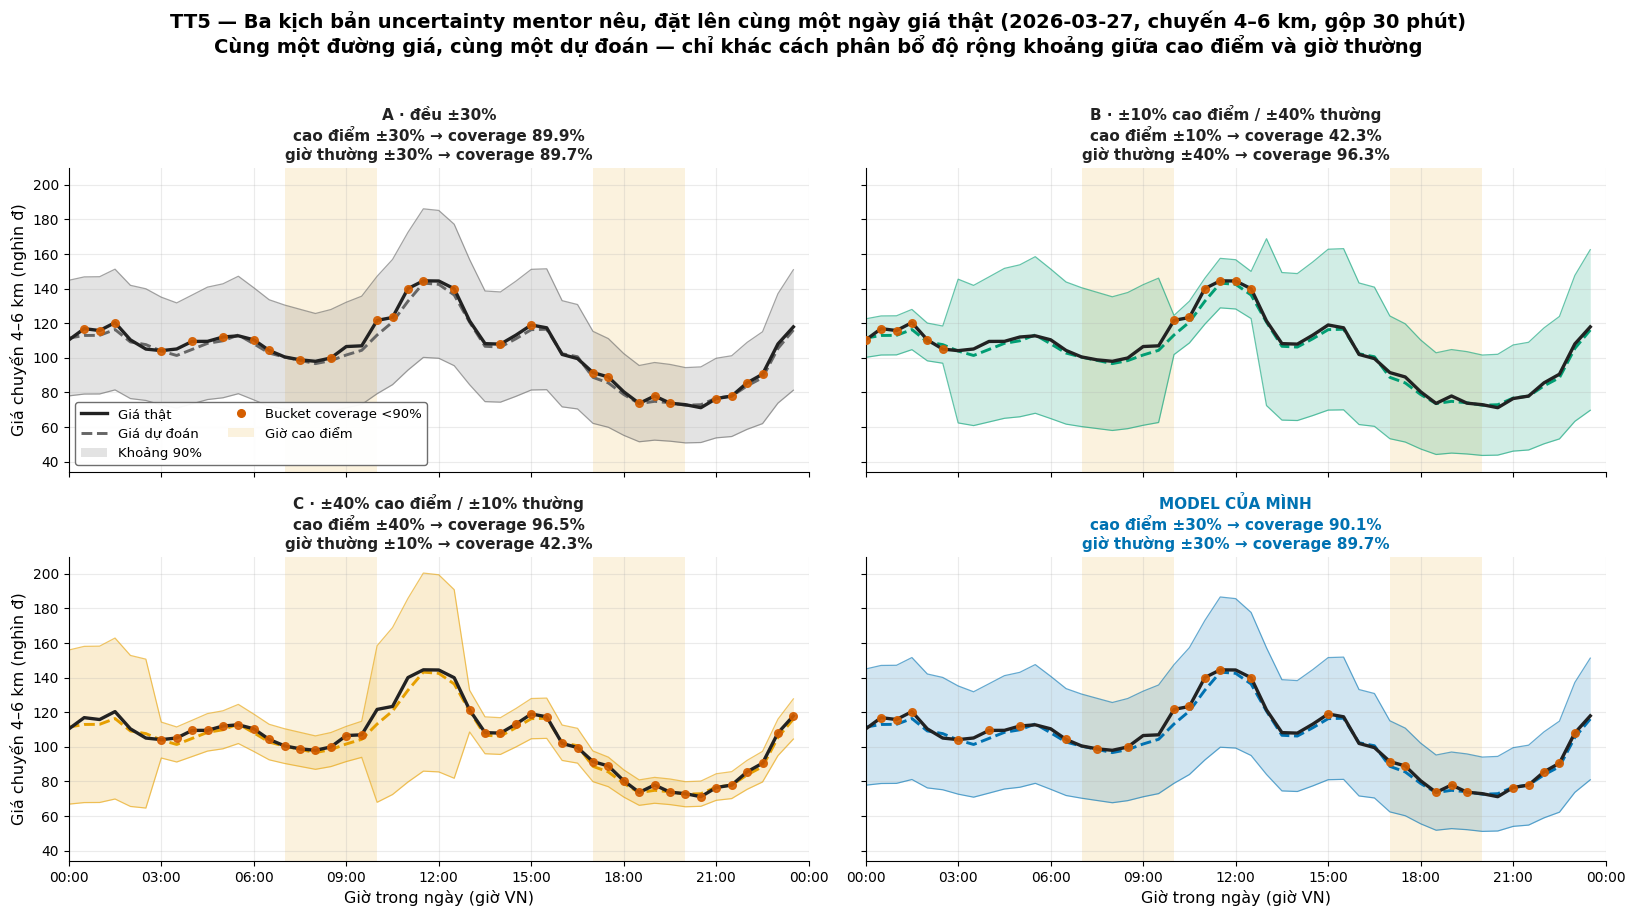

In [5]:
# ═════════ HINH TT5 — ba kich ban tren duong gia ═════════
fig, ax = plt.subplots(2, 2, figsize=(16.5, 9), sharex=True, sharey=True)
ax = ax.ravel()

ylo = min(g[[f"lo{i}" for i in range(4)]].min()) / 1000
yhi = max(g[[f"hi{i}" for i in range(4)]].max()) / 1000
pad = (yhi - ylo) * .06

for i, ((ten, _, mau), s) in enumerate(zip(KICH_BAN, TONG)):
    a = ax[i]
    for h1, h2 in CAO_DIEM:                       # nen gio cao diem
        a.axvspan(T0 + pd.Timedelta(hours=h1), T0 + pd.Timedelta(hours=h2 + 1),
                  color=ORANGE, alpha=.13, lw=0, zorder=0)
    a.fill_between(g.index, g[f"lo{i}"]/1000, g[f"hi{i}"]/1000, color=mau, alpha=.18, lw=0)
    a.plot(g.index, g[f"lo{i}"]/1000, color=mau, lw=.9, alpha=.6)
    a.plot(g.index, g[f"hi{i}"]/1000, color=mau, lw=.9, alpha=.6)
    a.plot(g.index, g.pred/1000, lw=2.1, color=mau, ls="--")
    a.plot(g.index, g.that/1000, lw=2.4, color=INK)

    ngoai = g[g[f"tr{i}"] < MUC]                  # coverage CAP CHUYEN hut cam ket
    if len(ngoai):
        a.plot(ngoai.index, ngoai.that/1000, "o", color=RED, ms=5.5, zorder=5, alpha=.9)

    a.set_title(f"{ten}\n"
                f"cao điểm ±{s['rong_cd']:.0%} → coverage {s['cvg_cd']:.1%}\n"
                f"giờ thường ±{s['rong_gt']:.0%} → coverage {s['cvg_gt']:.1%}",
                fontsize=11, fontweight="bold", color=mau if i == 3 else INK)
    if i % 2 == 0: a.set_ylabel("Giá chuyến 4–6 km (nghìn đ)")
    if i >= 2:     a.set_xlabel("Giờ trong ngày (giờ VN)")
    a.set_ylim(ylo - pad, yhi + pad)

ax[0].legend(handles=[
    Line2D([], [], color=INK, lw=2.4, label="Giá thật"),
    Line2D([], [], color=MUT, lw=2.1, ls="--", label="Giá dự đoán"),
    Patch(facecolor=MUT, alpha=.18, label=f"Khoảng {MUC:.0%}"),
    Line2D([], [], color=RED, marker="o", ls="", ms=5.5, label=f"Bucket coverage <{MUC:.0%}"),
    Patch(facecolor=ORANGE, alpha=.13, label="Giờ cao điểm"),
], frameon=True, framealpha=.95, edgecolor=MUT, ncol=2, loc="lower left", fontsize=9.5)

ax[0].set_xlim(T0, T0 + pd.Timedelta(days=1))
ax[0].xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle(f"TT5 — Ba kịch bản uncertainty mentor nêu, đặt lên cùng một ngày giá thật "
             f"({NGAY}, chuyến 4–6 km, gộp 30 phút)\n"
             f"Cùng một đường giá, cùng một dự đoán — chỉ khác cách phân bổ độ rộng khoảng "
             f"giữa cao điểm và giờ thường",
             fontweight="bold", fontsize=14, y=1.015)
fig.tight_layout()
fig.savefig(HINH / "TT5_ba_kich_ban_theo_thoi_gian.png")
plt.show()

**Nhìn hình thấy gì:**

- **A** — dải rộng đều, chấm đỏ rải khắp ngày ở mức nhẹ. Đây là mức "chấp nhận được ở mọi nơi".
- **B** — dải teo lại đúng lúc giá dựng đứng buổi cao điểm, nhìn *đẹp mắt* nhưng chấm đỏ **dồn
  hết vào hai vệt cam**. Đây là model "tự tin sai chỗ".
- **C** — dải phình ở cao điểm nên an toàn ở đó, nhưng chấm đỏ **phủ kín phần còn lại của ngày**.
  Và khoảng ±40% ở đúng lúc cần định giá gắt nhất thì rộng tới mức vô dụng cho vận hành.
- **Model mình** — hình dạng giống hệt A. Không mù ở chỗ quan trọng, nhưng cũng **không sắc hơn**
  ở chỗ quan trọng.

## 4. `TT6` — cái mình hứa vs cái mình giữ được

Hai panel cạnh nhau để thấy đánh đổi: hẹp khoảng ở một khung giờ **không miễn phí**, nó rút thẳng
từ coverage của đúng khung đó.

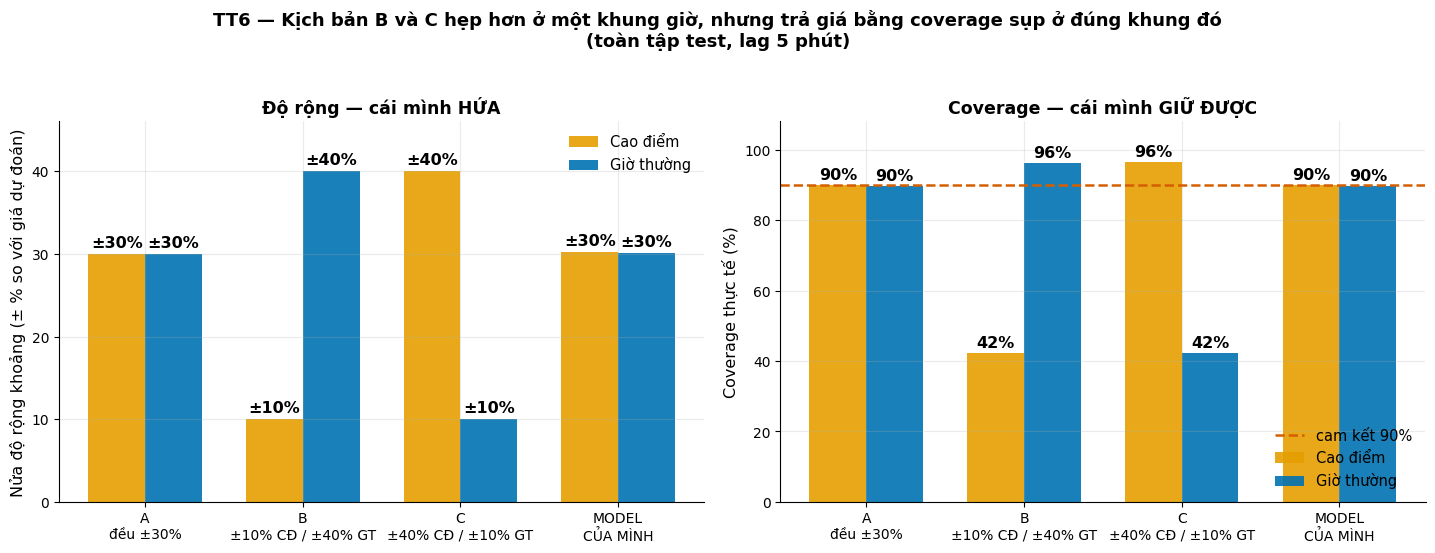

In [6]:
# ═════════ HINH TT6 — do rong hua vs coverage giu duoc ═════════
fig2, ax2 = plt.subplots(1, 2, figsize=(14.5, 5.4))
x = np.arange(len(TONG)); w = .36
ten_ngan = ["A\nđều ±30%", "B\n±10% CĐ / ±40% GT", "C\n±40% CĐ / ±10% GT", "MODEL\nCỦA MÌNH"]

a = ax2[0]
a.bar(x - w/2, [s["rong_cd"]*100 for s in TONG], w, color=ORANGE, alpha=.9, label="Cao điểm")
a.bar(x + w/2, [s["rong_gt"]*100 for s in TONG], w, color=BLUE,   alpha=.9, label="Giờ thường")
for i, s in enumerate(TONG):
    a.text(i - w/2, s["rong_cd"]*100 + .8, f"±{s['rong_cd']:.0%}", ha="center", fontweight="bold")
    a.text(i + w/2, s["rong_gt"]*100 + .8, f"±{s['rong_gt']:.0%}", ha="center", fontweight="bold")
a.set_xticks(x); a.set_xticklabels(ten_ngan); a.set_ylim(0, 46)
a.set_ylabel("Nửa độ rộng khoảng (± % so với giá dự đoán)")
a.set_title("Độ rộng — cái mình HỨA", fontweight="bold")
a.legend(frameon=False)

a = ax2[1]
a.bar(x - w/2, [s["cvg_cd"]*100 for s in TONG], w, color=ORANGE, alpha=.9, label="Cao điểm")
a.bar(x + w/2, [s["cvg_gt"]*100 for s in TONG], w, color=BLUE,   alpha=.9, label="Giờ thường")
a.axhline(MUC*100, color=RED, lw=1.8, ls="--", label=f"cam kết {MUC:.0%}")
for i, s in enumerate(TONG):
    a.text(i - w/2, s["cvg_cd"]*100 + 1.5, f"{s['cvg_cd']:.0%}", ha="center", fontweight="bold")
    a.text(i + w/2, s["cvg_gt"]*100 + 1.5, f"{s['cvg_gt']:.0%}", ha="center", fontweight="bold")
a.set_xticks(x); a.set_xticklabels(ten_ngan); a.set_ylim(0, 108)
a.set_ylabel("Coverage thực tế (%)")
a.set_title("Coverage — cái mình GIỮ ĐƯỢC", fontweight="bold")
a.legend(frameon=False, loc="lower right")

fig2.suptitle("TT6 — Kịch bản B và C hẹp hơn ở một khung giờ, nhưng trả giá bằng coverage sụp "
              "ở đúng khung đó\n(toàn tập test, lag 5 phút)",
              fontweight="bold", fontsize=13, y=1.02)
fig2.tight_layout()
fig2.savefig(HINH / "TT6_coverage_ba_kich_ban.png")
plt.show()

## 5. Kết luận — model mình thuộc kịch bản nào

In [7]:
m = TONG[3]
ty_le = m["rong_cd"] / m["rong_gt"]
print(f"Nửa độ rộng cao điểm  : ±{m['rong_cd']:.2%}")
print(f"Nửa độ rộng giờ thường: ±{m['rong_gt']:.2%}")
print(f"Tỷ lệ cao điểm / giờ thường: {ty_le:.3f}")
print()
if abs(ty_le - 1) < .05:
    print("⇒ KỊCH BẢN A — độ rộng phân bổ ĐỀU giữa cao điểm và giờ thường.")
elif ty_le < 1:
    print("⇒ KỊCH BẢN B — hẹp hơn ở cao điểm (chắc chắn hơn ở chỗ quan trọng).")
else:
    print("⇒ KỊCH BẢN C — rộng hơn ở cao điểm (mù ở chỗ quan trọng).")
print(f"\nCoverage: cao điểm {m['cvg_cd']:.1%} · giờ thường {m['cvg_gt']:.1%} "
      f"· chung {m['cvg']:.1%} (cam kết {MUC:.0%})")

Nửa độ rộng cao điểm  : ±30.20%
Nửa độ rộng giờ thường: ±30.07%
Tỷ lệ cao điểm / giờ thường: 1.004

⇒ KỊCH BẢN A — độ rộng phân bổ ĐỀU giữa cao điểm và giờ thường.

Coverage: cao điểm 90.1% · giờ thường 89.7% · chung 89.8% (cam kết 90%)


**Model của mình = kịch bản A**, tỷ lệ độ rộng cao điểm / giờ thường = **1,004**.

Đây là tin **trung tính**, cần nói thẳng cả hai mặt khi trình bày:

| | |
|---|---|
| ✅ **Không mù ở chỗ quan trọng** | Khác kịch bản C — khoảng không phình ra đúng lúc cần định giá gắt nhất. Coverage cao điểm **90,1%**, thậm chí nhỉnh hơn giờ thường |
| ⚠️ **Cũng không sắc hơn ở chỗ quan trọng** | Khác kịch bản B — không có lợi thế nào để khoe ở rush hour |

**Vì sao lại thế, và sửa được không.** Độ rộng đều là **hệ quả trực tiếp** của việc sai số đều:
`model/evaluation/09_chan_doan_model` xếp hạng 10 chiều bằng η² và thấy **giờ cao điểm gần như vô dụng**
(η² = 0,0000, biên độ 0,05 điểm), trong khi **quãng đường mạnh gấp ~100 lần** (η² = 0,0099).

⇒ Muốn đạt kịch bản B — hẹp ở rush hour — thì đòn bẩy **không nằm ở thời điểm**. Nó nằm ở quãng
đường. Chi tiết ở `model/evaluation/09_chan_doan_model` và `model/uncertainty/06_thu_hep_khoang`.